In [81]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

import cmocean.cm as cmo
from Python.open_tpose import tpose2012to2013

prefix = ['diag_state','diag_surf']
ds = tpose2012to2013(prefix)
ds['time'] = range(len(ds.time))

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


In [82]:
from Python.open_oisst import oisst2012to2013

oisst_data = oisst2012to2013()
print(oisst_data.shape)
oisst_data = oisst_data.transpose(2,1,0)

# add oisst data to ds and set the dimensions to be ds.time ds.XC and ds.YC
ds['oisst'] = (('time','YC','XC'), oisst_data)

(1128, 336, 731)


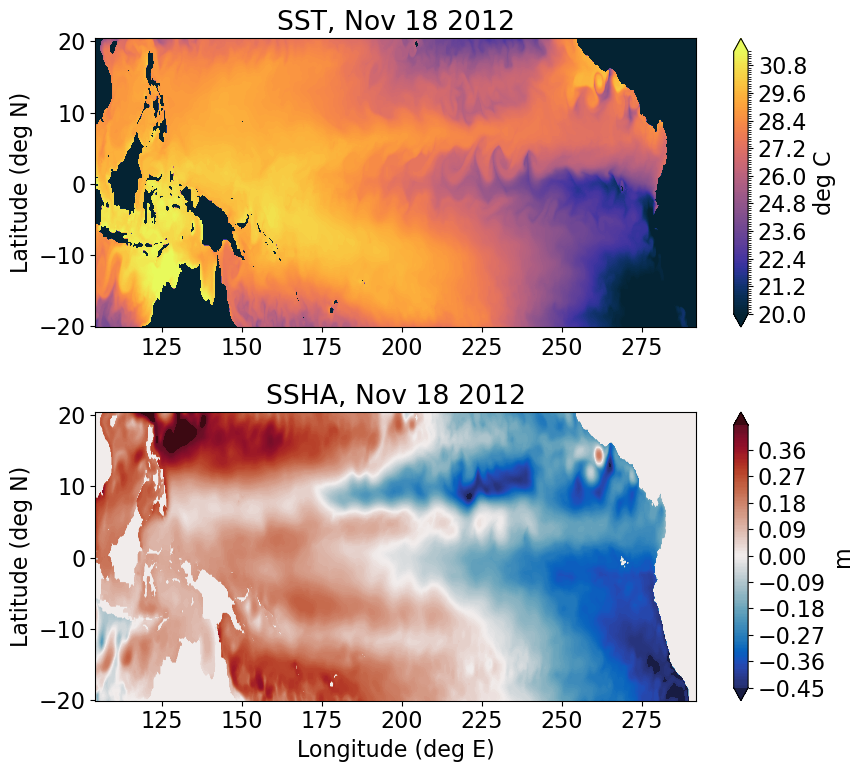

In [83]:
from matplotlib.colors import TwoSlopeNorm
plt.rcParams['font.size'] = 16

latMin = -20.0
latMax = 20.5

lats = ds.YC.data

latli = np.argmin(np.abs(lats - latMin))
latui = np.argmin(np.abs(lats - latMax)) + 1

levels = np.arange(20.0,31.5,0.1)
fig, ax = plt.subplots(figsize=(9,8),nrows=2)
ds.THETA[333,0,latli:latui,:].plot.contourf(ax=ax[0],cmap=cmo.thermal,levels=levels,cbar_kwargs={'label':'deg C'})
# ax[0].scatter(220.0,0.0,marker='*',color='tab:green',s=230)
ax[0].set_title('SST, Nov 18 2012')
ax[0].set_ylabel('Latitude (deg N)')
ax[0].set_xlabel('')
levels = np.arange(-0.45,0.45,0.005)
ds.ETAN[333,latli:latui,:].plot.contourf(ax=ax[1],cmap=cmo.balance,levels=levels,cbar_kwargs={'label':'m'},norm=TwoSlopeNorm(vmin=-0.5,vcenter=0,vmax=0.5))
# ax[1].scatter(220.0,0.0,marker='*',color='tab:green',s=230)
ax[1].set_title('SSHA, Nov 18 2012')
ax[1].set_ylabel('Latitude (deg N)')
ax[1].set_xlabel('Longitude (deg E)')
plt.tight_layout()

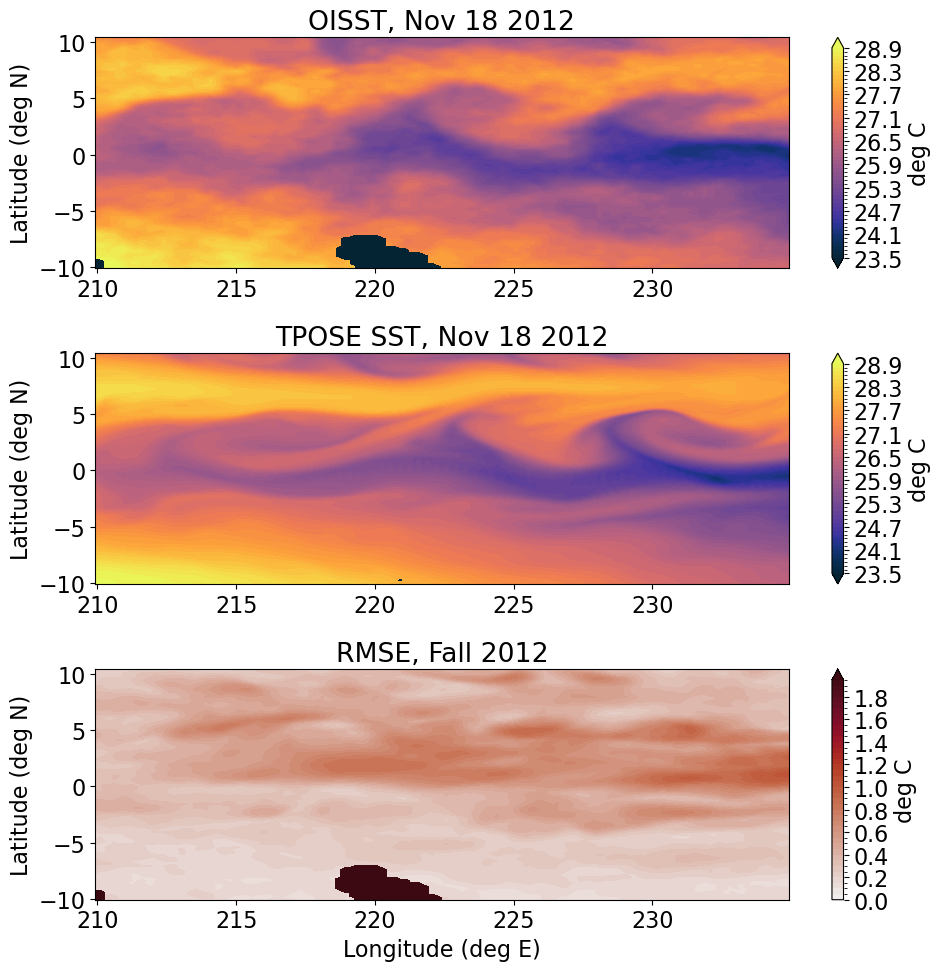

In [84]:
from matplotlib.colors import TwoSlopeNorm
plt.rcParams['font.size'] = 16

latMin = -10.0
latMax = 10.5
lonMin = 210.0
lonMax = 235.0

lats = ds.YC.data
lons = ds.XC.data

latli = np.argmin(np.abs(lats - latMin))
latui = np.argmin(np.abs(lats - latMax)) + 1
lonli = np.argmin(np.abs(lons - lonMin))
lonui = np.argmin(np.abs(lons - lonMax)) + 1

diff = (ds.THETA[274:366,0,latli:latui,lonli:lonui] - ds.oisst[274:366,latli:latui,lonli:lonui]).mean(dim='time')
RMSE = np.sqrt(((ds.THETA[274:366,0,latli:latui,lonli:lonui] - ds.oisst[274:366,latli:latui,lonli:lonui])**2).mean(dim='time'))


levels = np.arange(23.5,29.0,0.1)
fig, ax = plt.subplots(figsize=(10,10),nrows=3)
ds.THETA[333,0,latli:latui,lonli:lonui].plot.contourf(ax=ax[1],cmap=cmo.thermal,levels=levels,cbar_kwargs={'label':'deg C'})
ax[1].set_title('TPOSE SST, Nov 18 2012')
ax[1].set_ylabel('Latitude (deg N)')
ax[1].set_xlabel('')
ds.oisst[333,latli:latui,lonli:lonui].plot.contourf(ax=ax[0],cmap=cmo.thermal,levels=levels,cbar_kwargs={'label':'deg C'})
ax[0].set_title('OISST, Nov 18 2012')
ax[0].set_ylabel('Latitude (deg N)')
ax[0].set_xlabel('')
levels = np.arange(0,2.0,0.05)
RMSE.plot.contourf(ax=ax[2],cmap=cmo.amp,levels=levels,cbar_kwargs={'label':'deg C'})
ax[2].set_title('RMSE, Fall 2012')
ax[2].set_ylabel('Latitude (deg N)')
ax[2].set_xlabel('Longitude (deg E)')
plt.tight_layout()

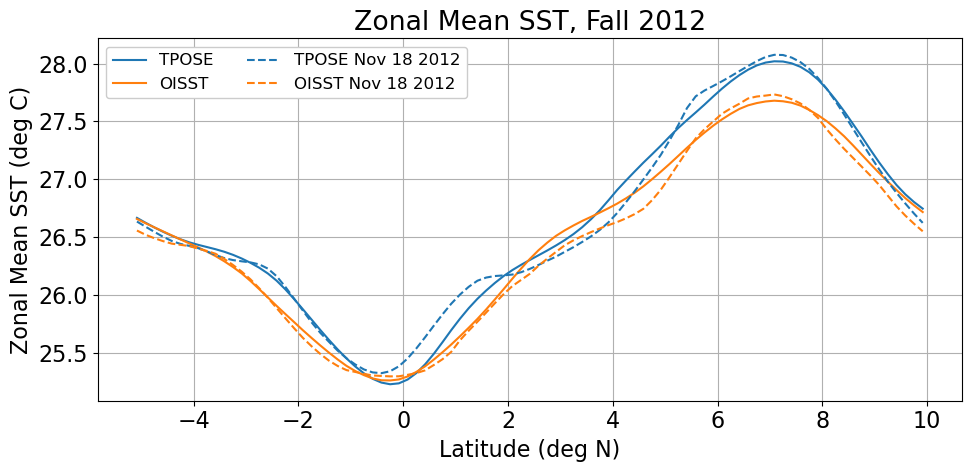

In [85]:
latMin = -5.0
latMax = 10.0
lonMin = 210.0
lonMax = 235.0

lats = ds.YC.data
lons = ds.XC.data

latli = np.argmin(np.abs(lats - latMin))
latui = np.argmin(np.abs(lats - latMax)) + 1
lonli = np.argmin(np.abs(lons - lonMin))
lonui = np.argmin(np.abs(lons - lonMax)) + 1

# zonal mean from -10 to 10 deg N
zonal_mean_tpose = ds.THETA[274:366,0,latli:latui,lonli:lonui].mean(dim=['XC','time'])
zonal_mean_oisst = ds.oisst[274:366,latli:latui,lonli:lonui].mean(dim=['XC','time'])
zonal_mean_oct20_tpose = ds.THETA[305,0,latli:latui,lonli:lonui].mean(dim='XC')
zonal_mean_oct20_oisst = ds.oisst[305,latli:latui,lonli:lonui].mean(dim='XC')
zonal_mean_nov12_tpose = ds.THETA[333,0,latli:latui,lonli:lonui].mean(dim='XC')
zonal_mean_nov12_oisst = ds.oisst[333,latli:latui,lonli:lonui].mean(dim='XC')

# plot latitude on x axis and zonal mean temp on y axis for both tpose and oisst
plt.figure(figsize=(10,5))
plt.plot(ds.YC[latli:latui], zonal_mean_tpose, label='TPOSE')
plt.plot(ds.YC[latli:latui], zonal_mean_oisst, label='OISST')
plt.plot(ds.YC[latli:latui], zonal_mean_nov12_tpose, label='TPOSE Nov 18 2012', color='C0', linestyle='--')
plt.plot(ds.YC[latli:latui], zonal_mean_nov12_oisst, label='OISST Nov 18 2012', color='C1', linestyle='--')
# plt.plot(ds.YC[latli:latui], zonal_mean_oct20_tpose, label='TPOSE Oct 20 2012', color='C0', linestyle=':')
# plt.plot(ds.YC[latli:latui], zonal_mean_oct20_oisst, label='OISST Oct 20 2012', color='C1', linestyle=':')
plt.xlabel('Latitude (deg N)')
plt.ylabel('Zonal Mean SST (deg C)')
plt.title('Zonal Mean SST, Fall 2012')
plt.legend(fontsize=12,ncol=2,framealpha=1)
plt.grid()
plt.tight_layout()
fig.savefig('Python/TPOSE_2012/PubFigs/zonal_mean_sst_fall_2012.png', dpi=300)

In [86]:
# for every point in time, take the zonal mean, then find the width (in km) between the first two crossings of 26 deg C
def find_width_of_26_deg_c_crossing(zonal_mean_sst, latitudes):
    # find the indices where the zonal mean SST crosses 26 deg C
    crossings = np.where(np.diff(np.sign(zonal_mean_sst - 26.0)))[0]
    
    if len(crossings) < 2:
        return np.nan  # not enough crossings to calculate width
    
    # get the latitudes of the first two crossings
    lat1 = latitudes[crossings[0]]
    lat2 = latitudes[crossings[1]]
    
    # calculate the width in km using the haversine formula
    R = 6371.0  # Earth radius in km
    phi1 = np.radians(lat1)
    phi2 = np.radians(lat2)
    
    width_km = R * np.abs(phi2 - phi1)
    
    return width_km

# apply this function to each time step in the zonal mean SST
widths_tpose = []
widths_oisst = []
for t in np.arange(274, 366):
    width_tpose = find_width_of_26_deg_c_crossing(ds.THETA[t,0,latli:latui,lonli:lonui].mean(dim='XC').values, ds.YC[latli:latui].values)
    width_oisst = find_width_of_26_deg_c_crossing(ds.oisst[t,latli:latui,lonli:lonui].mean(dim='XC').values, ds.YC[latli:latui].values)
    widths_tpose.append(width_tpose)
    widths_oisst.append(width_oisst)


75.94292


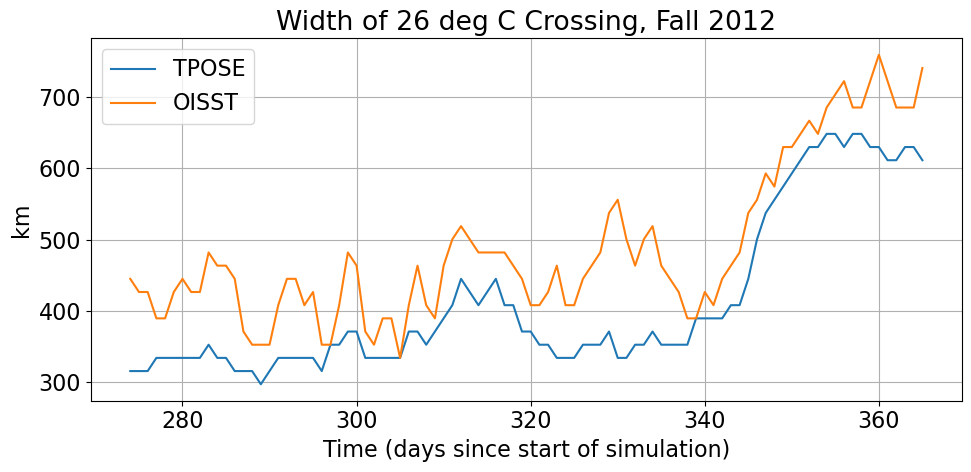

In [87]:
plt.figure(figsize=(10,5))
plt.plot(np.arange(274, 366), widths_tpose, label='TPOSE')
plt.plot(np.arange(274, 366), widths_oisst, label='OISST')
plt.xlabel('Time (days since start of simulation)')
plt.ylabel('km')
plt.title('Width of 26 deg C Crossing, Fall 2012')
plt.legend()
plt.grid()
plt.tight_layout()
fig.savefig('Python/TPOSE_2012/PubFigs/width_of_cold_tongue_fall_2012.png', dpi=300)

print(np.mean(np.array(widths_oisst) - np.array(widths_tpose)))


In [88]:
# take the time mean SST over the domain, then find the N and S edge of the 25.5 deg C contour at each longitude
SST_tpose = ds.THETA[274:366,0,latli:latui,lonli:lonui].mean(dim='time')
SST_oisst = ds.oisst[274:366,latli:latui,lonli:lonui].mean(dim='time')


# find N and S edge of 25.5 deg C contour at each longitude for both tpose and oisst
def find_edges_of_contour(sst, latitudes, contour_value=25.0):
    north_edges = []
    south_edges = []
    
    for i in range(sst.shape[1]):  # loop over longitudes
        sst_column = sst[:, i]

        crossings = np.where(np.diff(np.sign(sst_column - contour_value)))[0]
        
        # --- SIMPLE UPDATED LOGIC ---
        if len(crossings) == 1:
            # If there is only one value, give it to the N edge and make the S edge nan
            south_edges.append(np.nan)
            north_edges.append(latitudes[crossings[0]])
        elif len(crossings) >= 2:
            # Your original multi-crossing placement logic
            south_edges.append(latitudes[crossings[0]])
            north_edges.append(latitudes[crossings[1]])
        else:
            # No crossings found
            south_edges.append(np.nan)
            north_edges.append(np.nan)
        # ----------------------------
    
    return np.array(south_edges), np.array(north_edges)

south_edges_tpose, north_edges_tpose = find_edges_of_contour(SST_tpose[:-30].values, ds.YC[latli:(latui-30)].values)
south_edges_oisst, north_edges_oisst = find_edges_of_contour(SST_oisst[:-30].values, ds.YC[latli:(latui-30)].values)

south_edge_27_tpose, north_edge_27_tpose = find_edges_of_contour(SST_tpose[:-30].values, ds.YC[latli:(latui-30)].values, contour_value=26.25)
south_edge_27_oisst, north_edge_27_oisst = find_edges_of_contour(SST_oisst[:-30].values, ds.YC[latli:(latui-30)].values, contour_value=26.25)

widths_tpose = north_edges_tpose - south_edges_tpose
widths_oisst = north_edges_oisst - south_edges_oisst

widths_27_tpose = north_edge_27_tpose - south_edge_27_tpose
widths_27_oisst = north_edge_27_oisst - south_edge_27_oisst

diff = widths_oisst - widths_tpose
diff_27 = widths_27_oisst - widths_27_tpose

# convert to km
R = 6371.0  # Earth radius in km
widths_tpose_km = R * np.radians(widths_tpose)
widths_oisst_km = R * np.radians(widths_oisst)
diff_km = widths_oisst_km - widths_tpose_km
widths_27_tpose_km = R * np.radians(widths_27_tpose)
widths_27_oisst_km = R * np.radians(widths_27_oisst)
diff_27_km = widths_27_oisst_km - widths_27_tpose_km

In [89]:
diff_km_mean = np.nanmean(diff_km)
diff_27_km_mean = np.nanmean(diff_27_km)

print(f'Mean difference in width at 25.0 deg C: {diff_km_mean:.2f} km')
print(f'Mean difference in width at 26.25 deg C: {diff_27_km_mean:.2f} km')

Mean difference in width at 25.0 deg C: 78.69 km
Mean difference in width at 26.25 deg C: 56.73 km


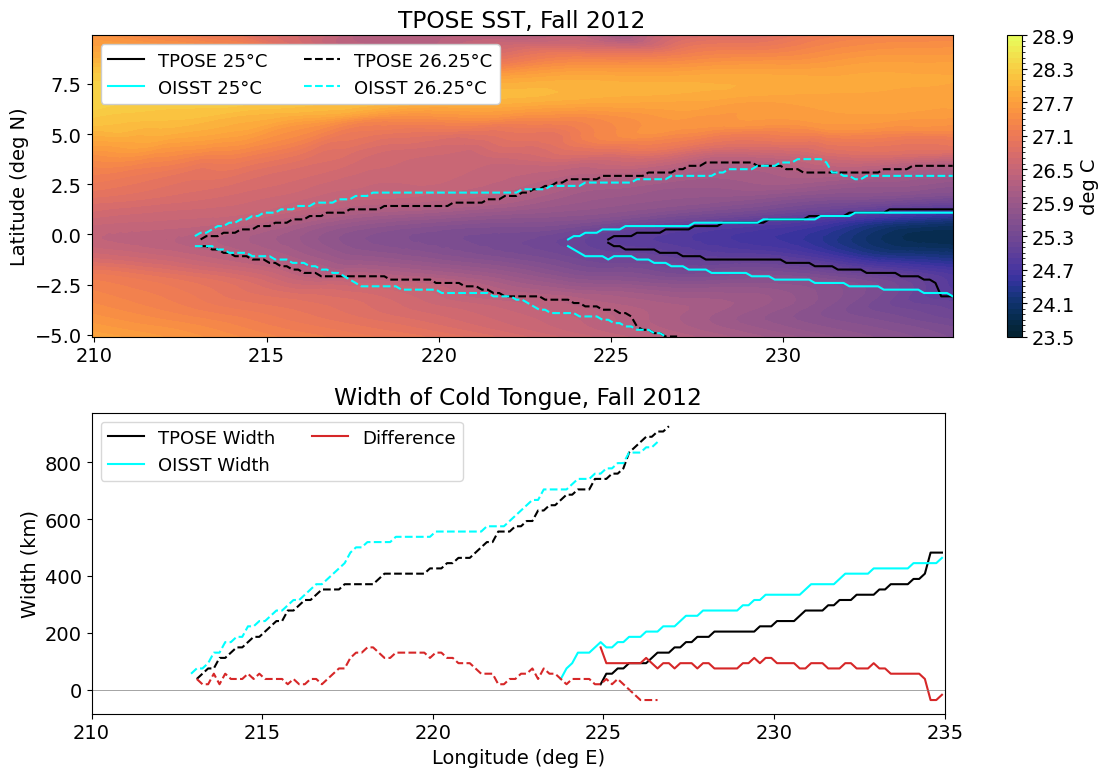

In [90]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
plt.rcParams['font.size'] = 14

# 1. Initialize a 2-row, 4-column GridSpec layout
fig = plt.figure(figsize=(12, 8))
gs = gridspec.GridSpec(2, 5, height_ratios=[1, 1])

# 2. Assign the axes based on column spanning
ax0 = fig.add_subplot(gs[0, :])  # Top plot: takes up 4/4 columns (full width)
ax1 = fig.add_subplot(gs[1, 0:4]) # Bottom plot: takes up 3/4 columns 

# --- TOP PLOT (SST & Contours) ---
# Let xarray handle its colorbar completely naturally on the right side of ax0
SST_tpose.plot.contourf(
    ax=ax0, 
    cmap=cmo.thermal, 
    x='XC', 
    levels=np.arange(23.5, 29.0, 0.1), 
    cbar_kwargs={'label': 'deg C'}
)

ax0.plot(ds.XC[lonli:lonui], south_edges_tpose, label='TPOSE 25°C', color='k')
ax0.plot(ds.XC[lonli:lonui], north_edges_tpose, label='__nolabel__', color='k')
ax0.plot(ds.XC[lonli:lonui], south_edges_oisst, label='OISST 25°C', color='cyan')
ax0.plot(ds.XC[lonli:lonui], north_edges_oisst, label='__nolabel__', color='cyan')
ax0.plot(ds.XC[lonli:lonui], south_edge_27_tpose, label='TPOSE 26.25°C', color='k', linestyle='--')
ax0.plot(ds.XC[lonli:lonui], north_edge_27_tpose, label='__nolabel__', color='k', linestyle='--')
ax0.plot(ds.XC[lonli:lonui], south_edge_27_oisst, label='OISST 26.25°C', color='cyan', linestyle='--')
ax0.plot(ds.XC[lonli:lonui], north_edge_27_oisst, label='__nolabel__', color='cyan', linestyle='--')
ax0.legend(fontsize=13, framealpha=1, ncol=2, loc='upper left')
ax0.set_title('TPOSE SST, Fall 2012')
ax0.set_xlabel('')
ax0.set_ylabel('Latitude (deg N)')

# --- BOTTOM PLOT (Widths) ---
ax1.plot(ds.XC[lonli:lonui], widths_tpose_km, label='TPOSE Width', color='k')
ax1.plot(ds.XC[lonli:lonui], widths_oisst_km, label='OISST Width', color='cyan')
ax1.plot(ds.XC[lonli:lonui], diff_km, label='Difference', color='tab:red')
ax1.plot(ds.XC[lonli:lonui], widths_27_tpose_km, label='__nolabel__', color='k', linestyle='--')
ax1.plot(ds.XC[lonli:lonui], widths_27_oisst_km, label='__nolabel__', color='cyan', linestyle='--')
ax1.plot(ds.XC[lonli:lonui], diff_27_km, label='__nolabel__', color='tab:red', linestyle='--')
ax1.axhline(0, color='gray', linewidth=0.5)
ax1.set_xlim(210,235)
ax1.set_title('Width of Cold Tongue, Fall 2012')
ax1.set_xlabel('Longitude (deg E)')
ax1.set_ylabel('Width (km)')
ax1.legend(fontsize=13, framealpha=0.75, ncol=2, loc='upper left')

# Adjust layout and save safely
plt.tight_layout()
fig.savefig('Python/TPOSE_2012/PubFigs/edges_of_cold_tongue_fall_2012.png', dpi=300)

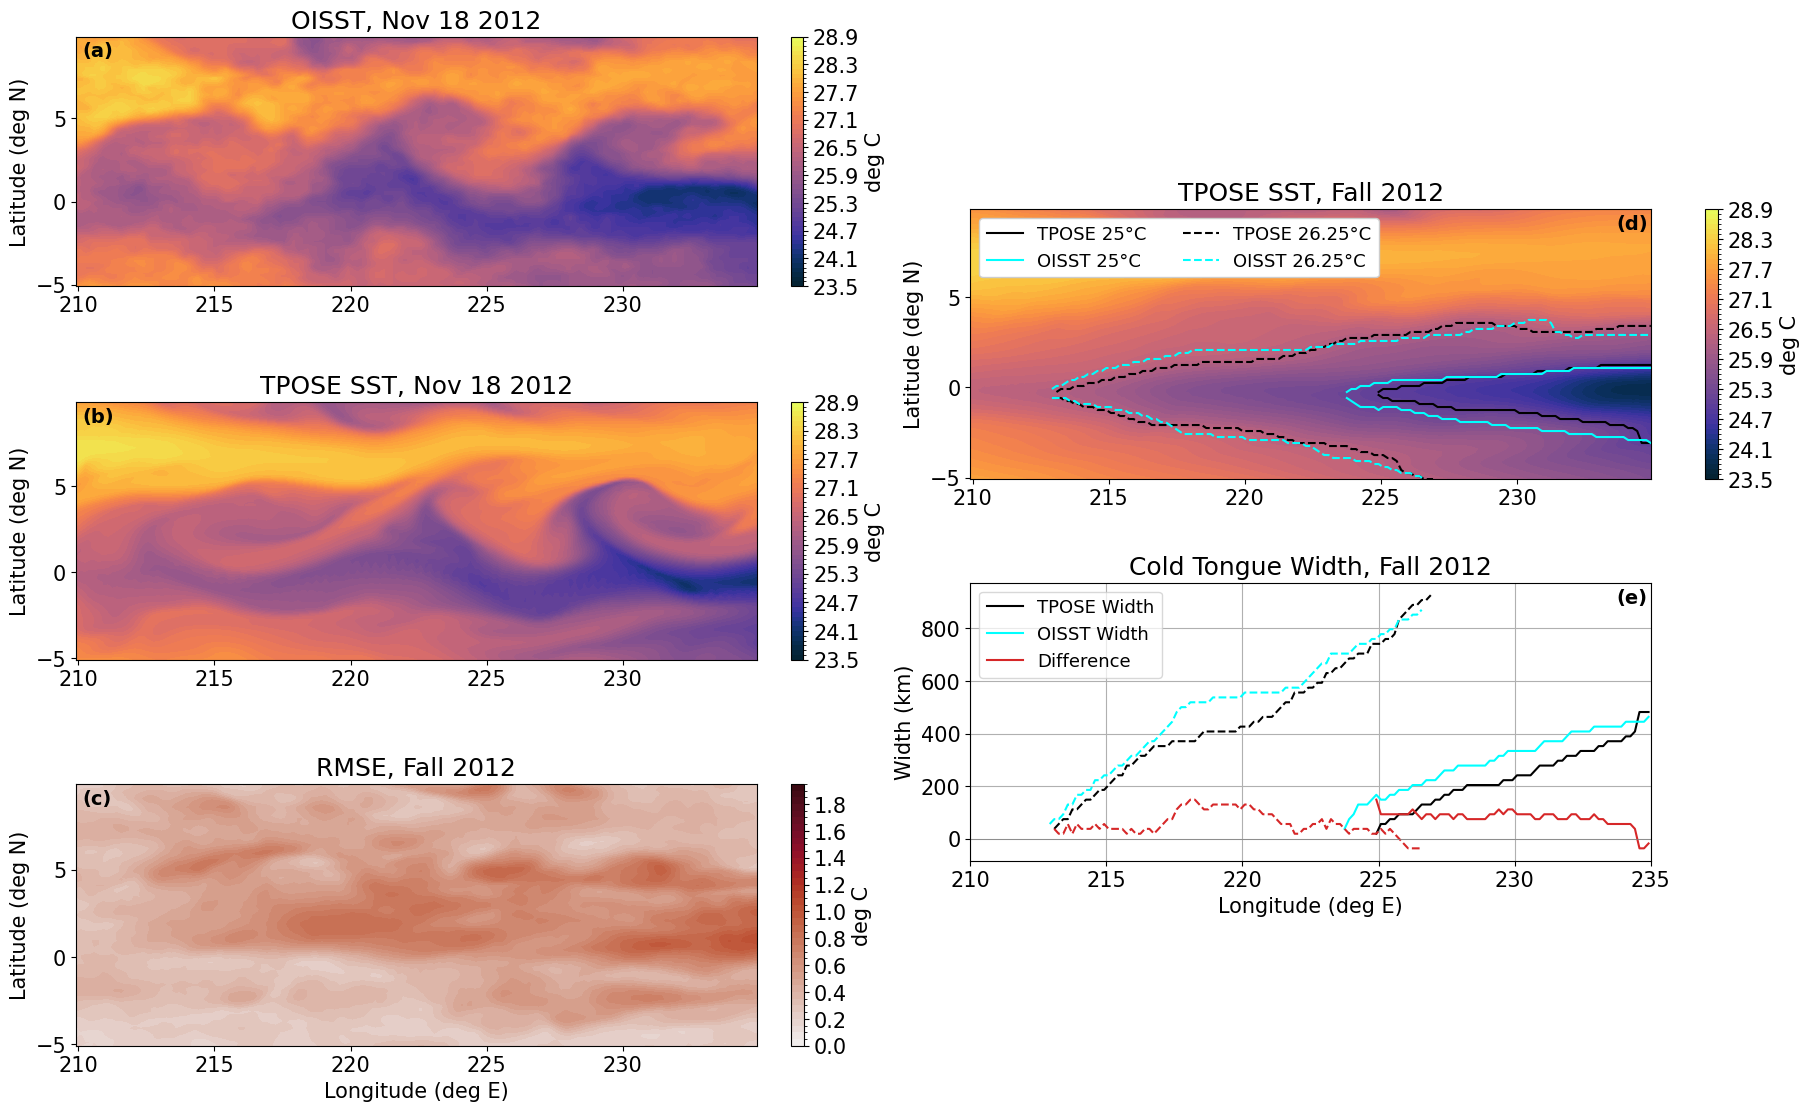

In [98]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Set consistent global font size
plt.rcParams['font.size'] = 15

RMSE = np.sqrt(((ds.THETA[274:366,0,latli:latui,lonli:lonui] - ds.oisst[274:366,latli:latui,lonli:lonui])**2).mean(dim='time'))

# Define distinct level variables to prevent overwriting bugs
levels_sst = np.arange(23.5, 29.0, 0.1)
levels_rmse = np.arange(0, 2.0, 0.05)

# Initialize a wide figure. constrained_layout ensures labels and colorbars do not overlap
fig = plt.figure(figsize=(18, 11), constrained_layout=True)

# 6 rows allows equal heights (2 rows per panel). 
# 10 columns allows 5 columns for the left half and 5 columns for the right half.
gs = gridspec.GridSpec(6, 10, figure=fig)

# --- LEFT COLUMN: 3 panels (Each spans 2 rows, full 5-column left width) ---
ax_left0 = fig.add_subplot(gs[0:2, 0:5])
ax_left1 = fig.add_subplot(gs[2:4, 0:5])
ax_left2 = fig.add_subplot(gs[4:6, 0:5])

# --- RIGHT COLUMN: 2 panels (Each spans 2 rows, vertically centered at rows 1-3 and 3-5) ---
ax_right0 = fig.add_subplot(gs[1:3, 5:10]) # Spans full 5-column right width to accommodate colorbar
ax_right1 = fig.add_subplot(gs[3:5, 5:10])  # Spans 4 columns to match the plotting area above it

# =====================================================================
# LEFT SIDE: SST & RMSE Panels
# =====================================================================

# 1. OISST Panel
ds.oisst[333, latli:latui, lonli:lonui].plot.contourf(
    ax=ax_left0, cmap=cmo.thermal, levels=levels_sst, cbar_kwargs={'label': 'deg C'}
)
ax_left0.set_title('OISST, Nov 18 2012')
ax_left0.set_ylabel('Latitude (deg N)')
ax_left0.set_xlabel('')
ax_left0.text(0.01, 0.98, '(a)',transform=ax_left0.transAxes,ha='left',va='top',fontsize=14,fontweight='bold',color='black')


# 2. TPOSE SST Panel
ds.THETA[333, 0, latli:latui, lonli:lonui].plot.contourf(
    ax=ax_left1, cmap=cmo.thermal, levels=levels_sst, cbar_kwargs={'label': 'deg C'}
)
ax_left1.set_title('TPOSE SST, Nov 18 2012')
ax_left1.set_ylabel('Latitude (deg N)')
ax_left1.set_xlabel('')
ax_left1.text(0.01, 0.98, '(b)',transform=ax_left1.transAxes,ha='left',va='top',fontsize=14,fontweight='bold',color='black')

# 3. RMSE Panel
RMSE.plot.contourf(
    ax=ax_left2, cmap=cmo.amp, levels=levels_rmse, cbar_kwargs={'label': 'deg C'}
)
ax_left2.set_title('RMSE, Fall 2012')
ax_left2.set_ylabel('Latitude (deg N)')
ax_left2.set_xlabel('Longitude (deg E)')
ax_left2.text(0.01, 0.98, '(c)',transform=ax_left2.transAxes,ha='left',va='top',fontsize=14,fontweight='bold',color='black')


# =====================================================================
# RIGHT SIDE: Cold Tongue Width Panels
# =====================================================================

# 4. TPOSE SST & Contours Panel
SST_tpose.plot.contourf(
    ax=ax_right0, 
    cmap=cmo.thermal, 
    x='XC', 
    levels=levels_sst, 
    cbar_kwargs={'label': 'deg C'}
)
ax_right0.plot(ds.XC[lonli:lonui], south_edges_tpose, label='TPOSE 25°C', color='k')
ax_right0.plot(ds.XC[lonli:lonui], north_edges_tpose, label='__nolabel__', color='k')
ax_right0.plot(ds.XC[lonli:lonui], south_edges_oisst, label='OISST 25°C', color='cyan')
ax_right0.plot(ds.XC[lonli:lonui], north_edges_oisst, label='__nolabel__', color='cyan')
ax_right0.plot(ds.XC[lonli:lonui], south_edge_27_tpose, label='TPOSE 26.25°C', color='k', linestyle='--')
ax_right0.plot(ds.XC[lonli:lonui], north_edge_27_tpose, label='__nolabel__', color='k', linestyle='--')
ax_right0.plot(ds.XC[lonli:lonui], south_edge_27_oisst, label='OISST 26.25°C', color='cyan', linestyle='--')
ax_right0.plot(ds.XC[lonli:lonui], north_edge_27_oisst, label='__nolabel__', color='cyan', linestyle='--')
ax_right0.legend(fontsize=13, framealpha=1, ncol=2, loc='upper left')
ax_right0.set_title('TPOSE SST, Fall 2012')
ax_right0.set_xlabel('')
ax_right0.set_ylabel('Latitude (deg N)')
ax_right0.text(0.95, 0.98, '(d)',transform=ax_right0.transAxes,ha='left',va='top',fontsize=14,fontweight='bold',color='black')

# 5. Widths Line Plot Panel
ax_right1.plot(ds.XC[lonli:lonui], widths_tpose_km, label='TPOSE Width', color='k')
ax_right1.plot(ds.XC[lonli:lonui], widths_oisst_km, label='OISST Width', color='cyan')
ax_right1.plot(ds.XC[lonli:lonui], diff_km, label='Difference', color='tab:red')
ax_right1.plot(ds.XC[lonli:lonui], widths_27_tpose_km, label='__nolabel__', color='k', linestyle='--')
ax_right1.plot(ds.XC[lonli:lonui], widths_27_oisst_km, label='__nolabel__', color='cyan', linestyle='--')
ax_right1.plot(ds.XC[lonli:lonui], diff_27_km, label='__nolabel__', color='tab:red', linestyle='--')
ax_right1.axhline(0, color='gray', linewidth=0.5)
ax_right1.set_xlim(210, 235)
ax_right1.grid()
ax_right1.set_title('Cold Tongue Width, Fall 2012')
ax_right1.set_xlabel('Longitude (deg E)')
ax_right1.set_ylabel('Width (km)')
ax_right1.legend(fontsize=13, framealpha=0.75, loc='upper left')
ax_right1.text(0.95, 0.98, '(e)',transform=ax_right1.transAxes,ha='left',va='top',fontsize=14,fontweight='bold',color='black')

# Save the high-quality unified dashboard
plt.savefig('Python/TPOSE_2012/PubFigs/combined_sst_plots.png', dpi=300)